결과 해석 , 의사 결정
- 통계 분석 - 더 좋은 선택을 하기 위함
- 매출 건수 매출 금액 예측 가능
- 매출 금액이 목표라면 손님이 얼마나 필요한지를 예측하는 것이 회귀

In [1]:
# 상권 매출 시각화 비교
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [2]:
import pandas as pd
df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


In [3]:
r = stats.linregress(df['당월_매출_건수'], df['당월_매출_금액'])
r

LinregressResult(slope=np.float64(57053.17611447167), intercept=np.float64(-918829232.2231295), rvalue=np.float64(0.8605464150264389), pvalue=np.float64(0.0), stderr=np.float64(477.68598196020986), intercept_stderr=np.float64(135427782.0477985))

In [ ]:
target_sales = 200_000_000
need_count = (target_sales - r.intercept) / r.slope # r.intercept - 절편, r.slope - 기울기
print(need_count)

19610.288303289322


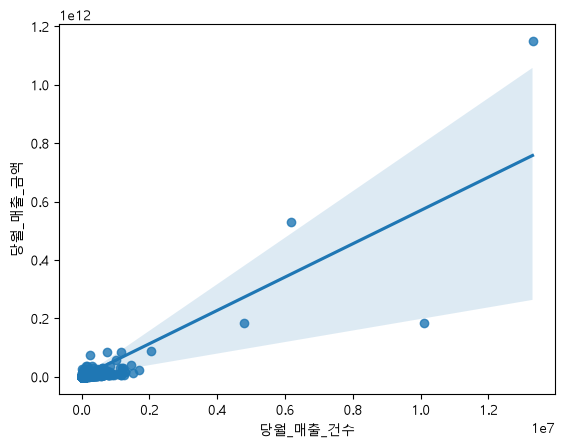

In [6]:
# 시각화
sns.regplot(data=df,
            x='당월_매출_건수',
            y ='당월_매출_금액')
            #  scatter_kws )
plt.show()

# 회귀식을 구하면 건수를 알면 매출 예상도 가능

- 여러 변수가 예측에 영향을 미칠 때
- 어떤 변수가 가장 p값으로 가려본다
- 숫자가 아닌 경우에는 계산이 어렵다. 범주형 변수는 -> 숫자로 변환 필요

In [ ]:
SSE - 오차 제곱의 합
MSE - 평균 제곱의 오차 
MAE - 오차 절대값의 합
RMSE - MSE 제곱 근

In [18]:
df1 = pd.read_csv(
    "../data/07-1_study_habits.csv"
)

In [19]:
import statsmodels.formula.api as smf
model = smf.ols(
    "시험점수 ~ 공부시간 + 용돈",
    data=df1
).fit()

In [20]:
print(model.rsquared)

0.6198339491711912


In [21]:
model.params

Intercept    57.386951
공부시간          3.983828
용돈           -0.000042
dtype: float64

In [22]:
model.pvalues

Intercept    2.276802e-66
공부시간         3.551190e-26
용돈           1.789752e-01
dtype: float64